## Day 50: End-to-End Classification Challenge 


In this challenge, you are going to carry out an end-to-end 
classification problem. You are going to train a model to 
predict the risk of someone suffering from heart disease. 

In [53]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn import metrics
import pickle

1. Import the Cardiovascular Study dataset using pandas. Use 
the pandas head() method to check that your data has 
loaded properly. 

In [54]:
df = pd.read_csv("cardiovascular_dataset.csv")
df.head()

,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,0,64,2.0,F,YES,3.0,0.0,0,0,0,221.0,148.0,85.0,NaN,90.0,80.0,1
1,1,36,4.0,M,NO,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0
2,2,46,1.0,F,YES,10.0,0.0,0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0
3,3,50,1.0,M,YES,20.0,0.0,0,1,0,233.0,158.0,88.0,28.26,68.0,94.0,1
4,4,64,1.0,F,YES,30.0,0.0,0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0


a. Check  if there are duplicates in the dataset. Check 
the shape of your dataset (number of columns and 
rows). 

In [55]:
df.duplicated().sum()

np.int64(0)

In [56]:
# Checking the shape of DataFrame
df.shape

(3390, 17)

b. Check for data types in the DataFrame. 


In [57]:
df.dtypes

id                   int64
age                  int64
education          float64
sex                 object
is_smoking          object
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

c. Is there any missing data in the DataFrame? 


In [58]:
# Check for missing values
df.isnull().sum()

id                   0
age                  0
education           87
sex                  0
is_smoking           0
cigsPerDay          22
BPMeds              44
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             38
sysBP                0
diaBP                0
BMI                 14
heartRate            1
glucose            304
TenYearCHD           0
dtype: int64

d. What are the minimum and maximum ages in the 
dataset? Create a histogram plot for the age 
column. 


In [59]:
# Finding the minimum age 
min_age = df.age.min()
print(f'The minimum age is: {min_age}')

The minimum age is: 32


In [60]:
# Finding the maximum age
max_age = df.age.max()
print(f"The maximum age is: {max_age}")

The maximum age is: 70


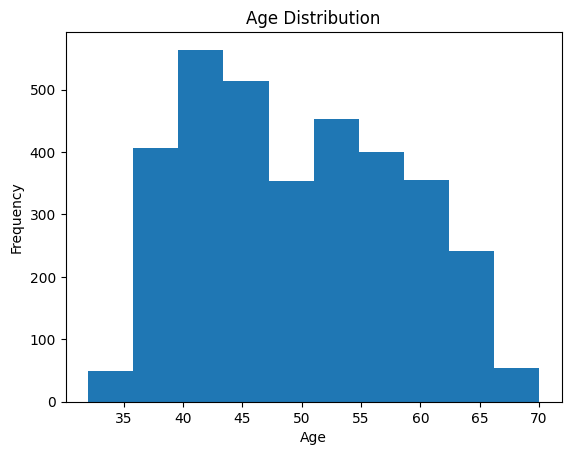

In [61]:
# Plotting a hist plot fo the age column 
df["age"].plot(kind="hist")
plt.xlabel(xlabel="Age")
plt.title("Age Distribution", fontsize=12)
plt.show()

e. Identify the target column. Compare the value count of ones and zeros in the column. Plot this on a histogram plot. 

In [71]:
# Using value_count to count uniques values in column
df.TenYearCHD.value_counts()

TenYearCHD
0    2879
1     511
Name: count, dtype: int64

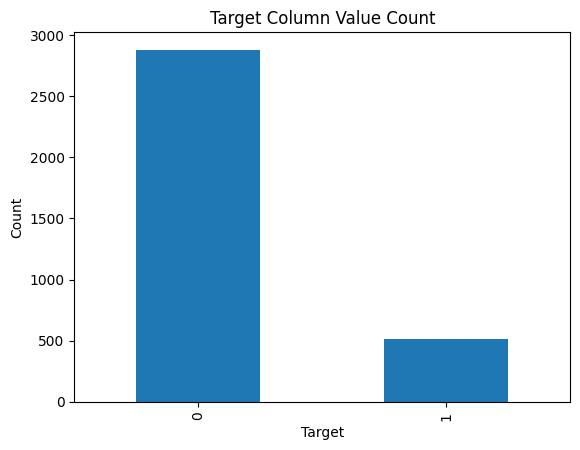

In [63]:
# Plotting the value count of the target column 
df.TenYearCHD.value_counts().plot(kind="bar")
plt.title("Target Column Value Count", fontsize=12)
plt.xlabel(xlabel="Target")
plt.ylabel(ylabel="Count")
plt.show()

2. Now, create a copy of the DataFrame. Clean up the data by 
dropping all the rows that have null values. Write a code to 
confirm that the null values have been dropped. 


In [69]:
df2 = df.copy()


In [72]:
df2 = df2.dropna(axis=0)

# Checking fro null values in the DataFram
df2.isnull().sum()


id                 0
age                0
education          0
sex                0
is_smoking         0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

3. Exploratory data analysis is important to ensure that we 
understand our data. Using the pandas quantile() method, 
count the number of outliers in each column with a 
numeric datatype. Using the boxplot() function from 
Seaborn, create a plot to visualize these outliers in the data. 
Your plot should only include columns with outliers. 

    Outliers are identified as data points that are below the 
lower fence (Q1 - 1.5 * IQR) or above the upper fence (Q3 + 
1.5 * IQR). 


In [73]:
# Returning all columns with numeric dtypes
numeric_dtype_columns = []
for column, values in df2.items():
    if values.dtypes != "object":
        numeric_dtype_columns.append(column)

# Function to return a count of outliers in each column
def count_outliers_in_columns(df, columns):
    Q1 = df[columns].quantile(0.25)
    Q3 = df[columns].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[((df[columns] < (Q1 - 1.5*IQR)) | (df[columns] > 
                                                     (Q3 + 1.5*IQR)))]
    return outliers[columns].count()

count_outliers_in_columns(df2, numeric_dtype_columns)

id                   0
age                  0
education            0
cigsPerDay           7
BPMeds              88
prevalentStroke     18
prevalentHyp         0
diabetes            79
totChol             34
sysBP               90
diaBP               50
BMI                 72
heartRate           56
glucose            146
TenYearCHD         444
dtype: int64

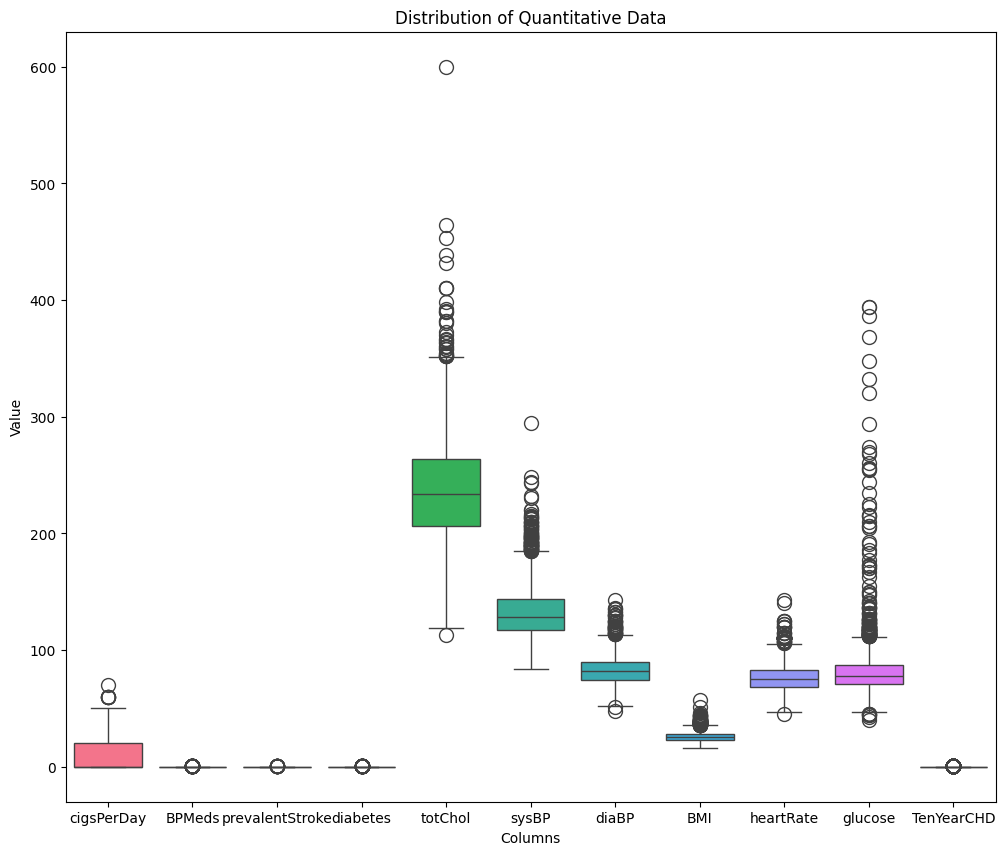

In [75]:
plt.subplots(figsize=(12, 10))
sns.boxplot(data=df2.drop(columns=(['id', 'age','education','prevalentHyp',
                                    'sex',
                                    'is_smoking']), inplace=False),
            saturation=0.95,
            fliersize=10,
            whis=1.5,
            width=0.8)

plt.xlabel(xlabel="Columns")
plt.ylabel(ylabel="Value")
plt.title("Distribution of Quantitative Data", fontsize=12)
plt.show()

4. You have decided to drop the outliers in the "BMI" column. 
Check the shape of  the DataFrame before and after 
dropping outliers. 


In [76]:
# Checking the shape before dropping outliers 
df2.shape

(2927, 17)

In [78]:
# Dropping outliers in a column
Q1 = df2.BMI.quantile(0.25)
Q3 = df2.BMI.quantile(0.75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 *IQR

df2 = df2[(df2.BMI > lower_bound) & (df2.BMI < upper_bound)]
df2.shape


(2855, 17)

5. You want to know the correlation between smoking and the 
risk of heart disease. Using crosstab, compare the 
"is_smoking" column to the "TenYearCHD" column. Is there 
a link between smoking and heart disease? Create a bar plot 
using pandas. 


In [79]:
pd.crosstab(df2.is_smoking, df.TenYearCHD)

TenYearCHD,0,1
is_smoking,,
NO,1236,198
YES,1192,229


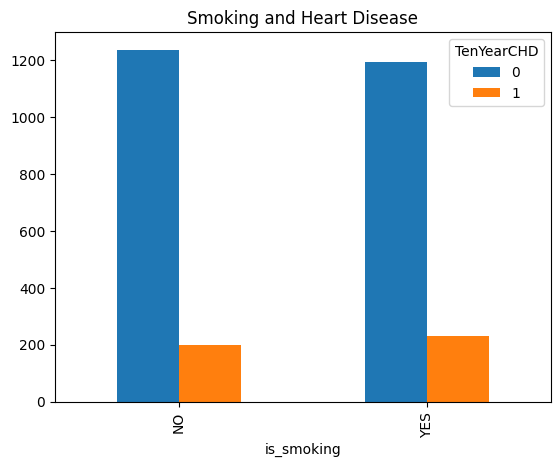

In [81]:
pd.crosstab(df2.is_smoking, df.TenYearCHD).plot(kind="bar")
plt.title("Smoking and Heart Disease", fontsize=12)
plt.show()

6. How many females and males are in the dataset? Do a 
crosstab of the "sex" column and the target column 
(TenYearCHD) to find a relationship between gender  and 
heart disease. Create a bar plot using pandas. 


In [82]:
df2.sex.value_counts()

sex
F    1561
M    1294
Name: count, dtype: int64

In [84]:
pd.crosstab(df2.sex, df2.TenYearCHD)

TenYearCHD,0,1
sex,,
F,1374,187
M,1054,240


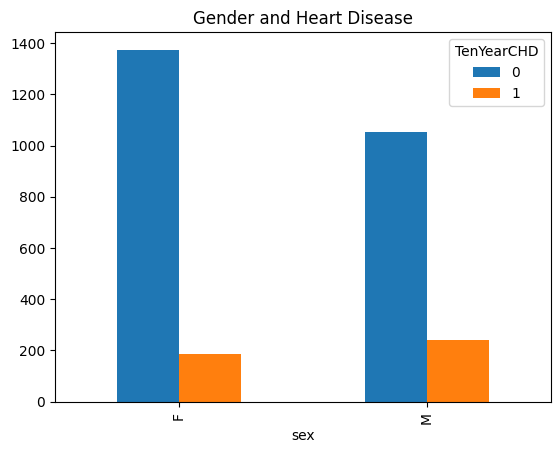

In [85]:
pd.crosstab(df2.sex, df.TenYearCHD).plot(kind="bar")
plt.title("Gender and Heart Disease", fontsize=12)
plt.show()

7.  Is there a link between a person’s cholesterol levels, their 
age, and heart disease? To answer this question, plot a 
scatter plot using Matplotlib of the "totChol" column and 
the "age" column for people that have heart disease in the 
"TenYearCHD" column (remember that 1 is for heart 
disease and 0 is for non-heart disease). 


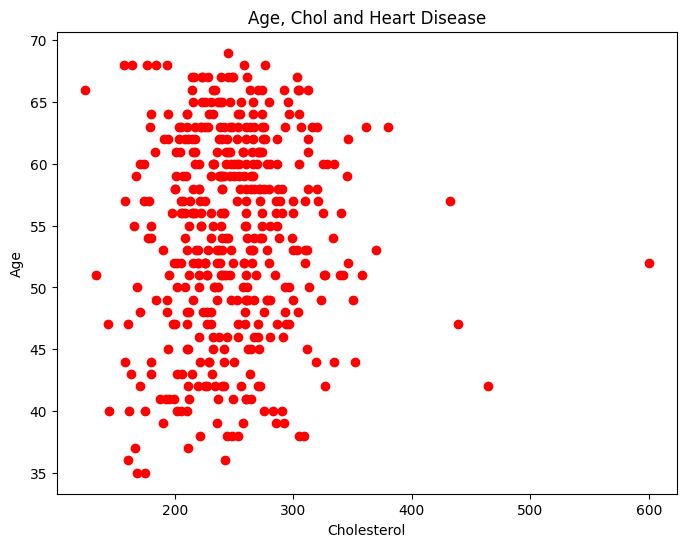

In [87]:
plt.subplots(figsize=(8, 6))
plt.scatter(df2.totChol[df2.TenYearCHD==1],
            df2.age[df.TenYearCHD==1], c= "red")
plt.xlabel(xlabel = "Cholesterol")
plt.ylabel(ylabel = "Age")
plt.title("Age, Chol and Heart Disease", fontsize=12)
plt.show()

8. Is there a link between heart rate, age, and the risk of heart 
disease? To answer this question, plot a scatter plot using 
Matplotlib. 


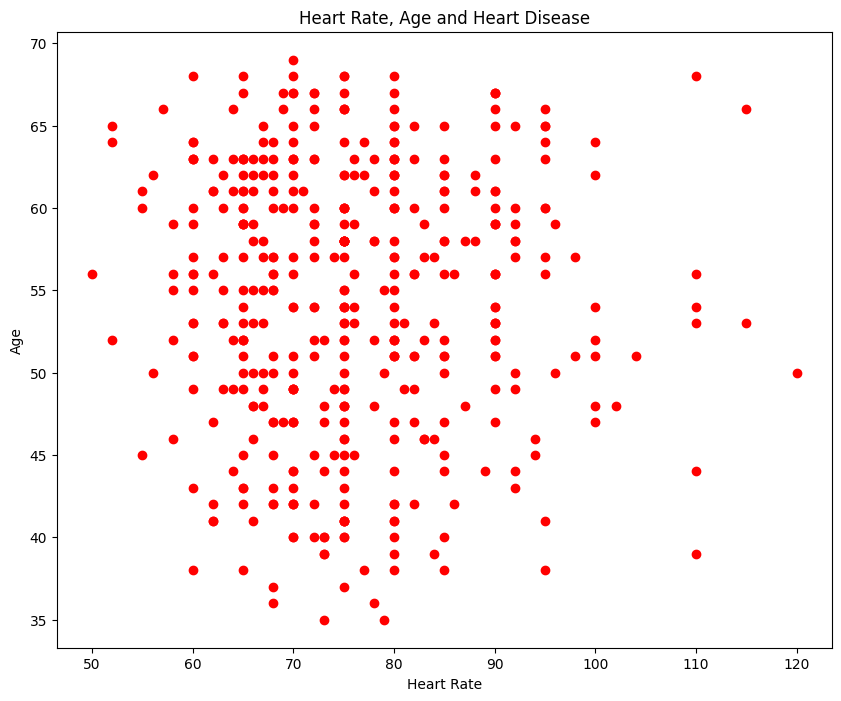

In [89]:
plt.subplots(figsize=(10,8))
plt.scatter(df2.heartRate[df2.TenYearCHD==1],
            df2.age[df2.TenYearCHD==1], c="red")
plt.xlabel(xlabel="Heart Rate")
plt.ylabel(ylabel="Age")
plt.title("Heart Rate, Age and Heart Disease", fontsize = 12)
plt.show()


9. Let’s consider the social aspect: Is there a link between a 
person’s level of education and heart disease? Plot a bar 
plot comparing the number of people with heart disease to 
those without heart disease at all levels of education. Try 
using a crosstab. Use Matplotlib. 


In [90]:
pd.crosstab(df2.education, df2.TenYearCHD)

TenYearCHD,0,1
education,,
1.0,971,216
2.0,756,107
3.0,424,60
4.0,277,44


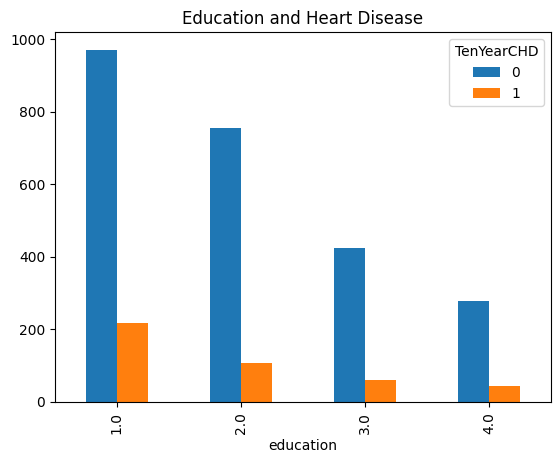

In [91]:
pd.crosstab(df2.education, df2.TenYearCHD).plot(kind='bar')
plt.title("Education and Heart Disease", fontsize = 12)
plt.show()


10. Using the Sklearn LabelEncoder, transform the non
numeric columns into numeric ones. To further understand 
the relationship between variables, create a heatmap using  
the Seaborn library.  


In [92]:
le = LabelEncoder()
df2['sex'] = le.fit_transform(df2['sex'])
df2['is_smoking'] = le.fit_transform(df2['is_smoking'])
df2.head(5)


,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
1,1,36,4.0,1,0,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0
2,2,46,1.0,0,1,10.0,0.0,0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0
3,3,50,1.0,1,1,20.0,0.0,0,1,0,233.0,158.0,88.0,28.26,68.0,94.0,1
4,4,64,1.0,0,1,30.0,0.0,0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0
5,5,61,3.0,0,0,0.0,0.0,0,1,0,272.0,182.0,121.0,32.80,85.0,65.0,1


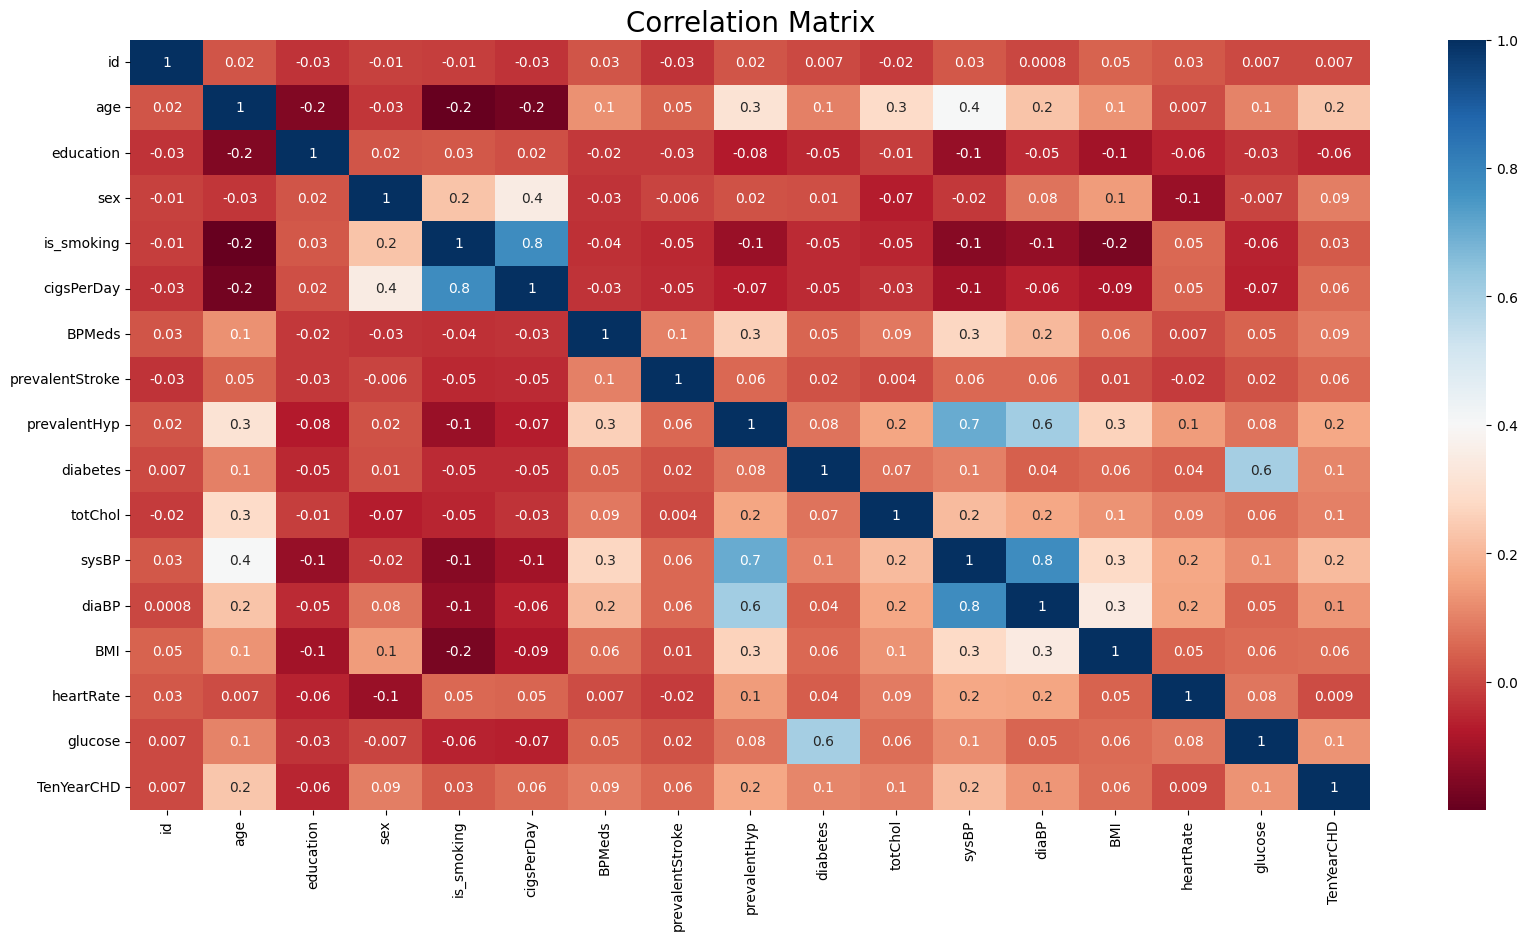

In [93]:
# Calculate the correlation matrix
corr = df2.corr()

# Plot the heatmap of the correlation matrix
plt.subplots(figsize=(20,10))
sns.heatmap(corr,
            annot=True,
            cmap="RdBu",
            fmt='.0g',
            vmax=1,
           )

plt.title("Correlation Matrix", fontsize = 20)
plt.show()


11. Separate the DataFrame into X and y values. The y value 
will be the target column. The target column is 
TenYearCHD. The variables will be the remainder of the 
channels. Since the dataset has a numeric index, the "id" column seems redundant; please drop it. Check the 
shapes of X and y and ensure that they have an equal 
number of rows. 


In [94]:
# Extracting the target column from DataFrame
y = df2["TenYearCHD"]

# Droping the target and 'id' columns from variables
X = df2.drop(columns=["TenYearCHD", "id"])


In [95]:
# check the shape of X and y
X.shape, y.shape

((2855, 15), (2855,))

12. Split the data into training and testing sets. 20% of the data 
will be testing data. Scale the data using StandardScaler 
from the Sklearn library. Train the logistic regression 
model with the data. Test the accuracy score of the model 
on the testing sets.  


In [96]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

# Scale the data using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train the classifier
clf = LogisticRegression()
clf.fit(X_train, y_train)

# Evaluate the classifier on the test data
score_on_test_data = clf.score(X_test, y_test)

print(f'Test data accuracy: {score_on_test_data*100:.2f}%')


Test data accuracy: 85.81%


13. Now that we have our accuracy score on the test data, try 
hyperparameter tuning the logistic regression model using 
RandomizedSearchCV. Hyperparameter tuning is simply 
searching for the best combination of parameters for the 
best performance of the machine learning model. Use the 
best parameters obtained by RandomizedSearchCV to 
instantiate a LogisticRegression model and fit the training 
data. What is the accuracy score? 


In [97]:
distributions = {
    'penalty' : ['l1', 'l2', 'elasticnet'],
    'max_iter' : range(100, 800),
    'warm_start' : [True, False],
    'solver' : ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag'],
    'C' : np.logspace(-1, 1, 22)
}

clf = RandomizedSearchCV(estimator = LogisticRegression(),
                         param_distributions = distributions,
                         n_iter = 100,
                         scoring = 'accuracy',
                         n_jobs = -1,
                         verbose = 1,
                         random_state = 42)

# Fit the data with RandomizedSearchCV
clf.fit(X_train, y_train)

# Getting the best hyperparameters
best_params = clf.best_params_

# Instantiating the model using the best score
clf_best_dt = LogisticRegression(**best_params)

# Using the best params to fit the classifier
clf_best_dt.fit(X_train, y_train)

# Getting accuracy score
accuracy_score = clf_best_dt.score(X_test, y_test)

print(f'Test data accuracy: {accuracy_score*100:.2f}%')


Fitting 5 folds for each of 100 candidates, totalling 500 fits
Test data accuracy: 85.99%


14. Above, you have evaluated the results using the accuracy 
score. The accuracy score does not give a complete picture 
of the performance of our model. We need to use other 
methods to evaluate or model.  


a. Use the confusion_matrix to obtain an understanding of what the model is predicting right and what it is predicting wrong in the test data. 


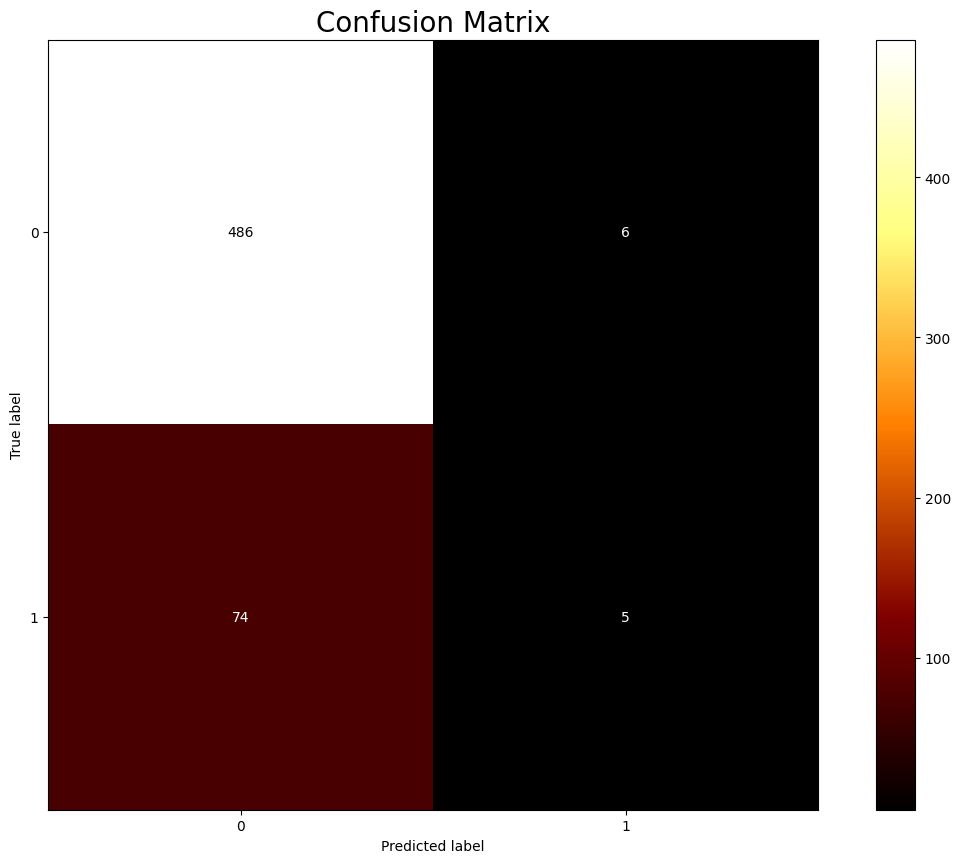

In [98]:
# predicting out on test data
y_pred = clf_best_dt.predict(X_test)

disp = ConfusionMatrixDisplay.from_predictions( y_test, y_pred,
                                                cmap=plt.cm.afmhot,
                                                display_labels = clf_best_dt.classes_)

fig = disp.ax_.get_figure()
fig.set_figwidth(15)
fig.set_figheight(10)
plt.title("Confusion Matrix", fontsize=20)
plt.show()


b. Generate a ROC curve plot for the results. Use the 
predict_proba() method to calculate the AUC.  What 
is the significance of the Roc curve? 


In [99]:
# Using proba to get class probabilities
y_predict = clf_best_dt.predict_proba(X_test)[:,1]

# Calculating AUC_score
auc_score = roc_auc_score(y_test, y_predict)
print(f'Auc score: {auc_score:.2f}')


Auc score: 0.73


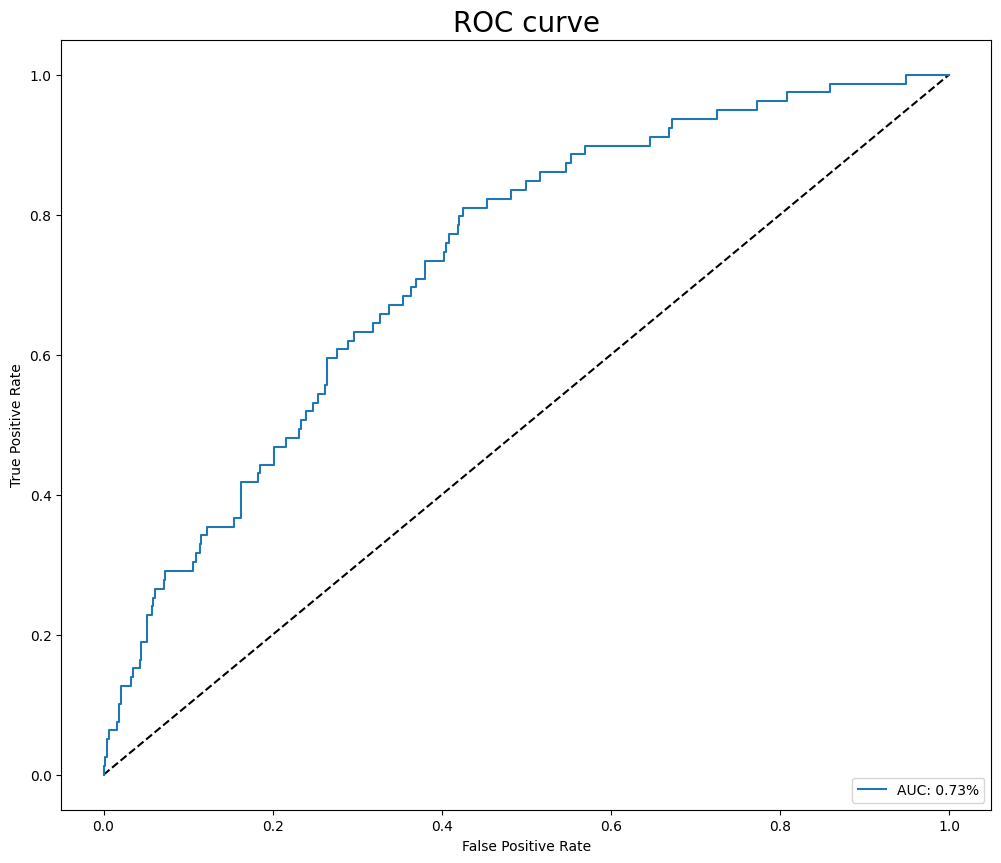

In [100]:
fpr, tpr, thresholds = roc_curve(y_test, y_predict)

plt.figure(figsize=(12,10))
plt.plot([0,1],[0,1],"k--")
plt.plot(fpr, tpr, label=f'AUC: {auc_score:.2f}%')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve', fontsize=20)
plt.legend(loc='lower right')
plt.show()


c. Generate the classification report using Sklearn. The 
classification report will evaluate the following 
matrices: precision, recall, and F1-score. What can you 
conclude from each metric? Using this report, can 
you conclude if there is a data imbalance in the 
dataset? 


In [101]:
# Target names
names = ['No Risk of Heart Disease', 'Risk of Heart Disease']
print(classification_report(y_test, y_pred, target_names=names))


                          precision    recall  f1-score   support

No Risk of Heart Disease       0.87      0.99      0.92       492
   Risk of Heart Disease       0.45      0.06      0.11        79

                accuracy                           0.86       571
               macro avg       0.66      0.53      0.52       571
            weighted avg       0.81      0.86      0.81       571



The classification report shows three key metrics. Precision for the minority class (risk of heart disease) is only 45%, meaning that when the model predicts someone is at risk, it is correct less than half the time. Recall is extremely low at 6%, showing the model fails to identify most true heart‑disease cases. The F1‑score, which balances precision and recall, is only 11% for the minority class but 92% for the majority class. This huge gap, along with the support values (492 samples for “no risk” vs. only 79 for “risk”), clearly shows the dataset is highly imbalanced, causing the model to perform well on the majority class but poorly on the minority class.

15. Is there another way we can obtain even better results? 
How can we deal with the imbalanced data? Explain. 


To improve results, we could gather more data, try stronger models such as RandomForest, KNN, or Decision Trees, and use GridSearchCV for more thorough hyperparameter tuning. Since the dataset is imbalanced, we can apply resampling techniques from the imbalanced‑learn library—such as oversampling the minority class (SMOTE), undersampling the majority class, or using hybrid methods—to help the model learn patterns in the minority class more effectively and improve overall performance.

16. Save the model you trained above (question 13). Save the 
model using the pickle library. After saving the model, load 
it.  

In [102]:
# Save the model
with open('model.pkl', 'wb') as file:
    pickle.dump(clf_best_dt, file)


In [103]:
# Loading the saved model
saved_model = pickle.load(open('model.pkl', 'rb'))
score = saved_model.score(X_test, y_test)
score


0.8598949211908932